# 10 — Síntese Multidimensional Final dos Modelos

Este notebook consolida as diferentes dimensões de avaliação dos classificadores desenvolvidos para a predição da resolução de reclamações.

## Dimensões integradas

1. **Desempenho classificatório**
   - Precision
   - Recall
   - F1-score

2. **Discriminação**
   - ROC-AUC
   - PR-AUC
   - KS

3. **Desempenho operacional**
   - regra previamente congelada: Top-k ou threshold
   - Precision operacional
   - Recall operacional
   - Lift
   - cobertura

4. **Generalização temporal**
   - comparação Teste/Validação Operacional × OOT

5. **Calibração**
   - Brier Score
   - Brier Skill Score

6. **Estabilidade temporal**
   - PSI da distribuição dos scores

7. **Interpretabilidade**
   - Permutation Importance
   - coeficientes da Regressão Logística
   - importância interna das árvores
   - SHAP, quando disponível

## Princípio metodológico

Este notebook **não altera nenhum modelo**.

Não haverá:

- novo tuning;
- alteração de variáveis;
- novo threshold;
- nova definição de Top-k;
- recalibração utilizando o OOT;
- seleção automática do modelo final por uma única métrica ou por um escore arbitrário.

A escolha final, se realizada, deverá ser justificada a partir da avaliação conjunta das dimensões e do objetivo de negócio.


## 1. Bibliotecas e configurações


In [1]:
from pathlib import Path
import json
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    roc_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 400)
pd.set_option("display.max_colwidth", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.5f}")

RANDOM_STATE = 42

# 300 repetições oferecem uma estimativa inicial reproduzível.
# Para a versão final do artigo, pode-se elevar para 1000.
N_BOOTSTRAP = 300
ALFA = 0.05


## 2. Diretórios e arquivos das etapas anteriores


In [2]:
PROJECT_DIR = Path(r"C:\UnB\script_md")

PROCESSADOS_DIR = PROJECT_DIR / "Base de dados" / "processados"
MODELS_DIR = PROJECT_DIR / "outputs" / "modelos"
TABLES_DIR = PROJECT_DIR / "outputs" / "tabelas"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figuras"
CONFIG_DIR = PROJECT_DIR / "outputs" / "config"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROCESSADOS_DIR / "dataset_modelagem_preparado.csv"

CONFIG_OPERACIONAL_FILE = (
    CONFIG_DIR /
    "configuracao_operacional_congelada.json"
)

REGISTRO_OOT_FILE = (
    CONFIG_DIR /
    "registro_avaliacao_oot.json"
)

FILES = {
    "oot_050":
        TABLES_DIR / "oot_metricas_threshold_050.csv",

    "oot_operacional":
        TABLES_DIR / "oot_resultados_regra_operacional.csv",

    "comparacao_050":
        TABLES_DIR / "oot_comparacao_teste_oot_threshold_050.csv",

    "comparacao_operacional":
        TABLES_DIR / "oot_comparacao_regra_operacional.csv",

    "brier":
        TABLES_DIR / "calibracao_brier_teste_oot.csv",

    "psi_scores":
        TABLES_DIR / "estabilidade_psi_scores.csv",

    "permutation":
        TABLES_DIR / "interpretabilidade_permutation_importance.csv",

    "ranking_interpretabilidade":
        TABLES_DIR / "interpretabilidade_ranking_comparativo.csv",

    "consenso_interpretabilidade":
        TABLES_DIR / "interpretabilidade_consenso_variaveis.csv",

    "tvd_operacional":
        TABLES_DIR / "interpretabilidade_tvd_grupo_priorizado.csv",

    "shap":
        TABLES_DIR / "interpretabilidade_shap_agregado.csv"
}

arquivos_obrigatorios = [
    INPUT_FILE,
    CONFIG_OPERACIONAL_FILE,
    REGISTRO_OOT_FILE,
    FILES["oot_050"],
    FILES["oot_operacional"],
    FILES["brier"],
    FILES["psi_scores"],
    FILES["permutation"]
]

faltantes = [
    str(caminho)
    for caminho in arquivos_obrigatorios
    if not caminho.exists()
]

if faltantes:
    raise FileNotFoundError(
        "Arquivos obrigatórios ausentes:\n- " +
        "\n- ".join(faltantes)
    )

print("Arquivos obrigatórios localizados.")
print(
    f"SHAP disponível para síntese: "
    f"{FILES['shap'].exists()}"
)


Arquivos obrigatórios localizados.
SHAP disponível para síntese: True


## 3. Configuração congelada e registro OOT


In [3]:
with CONFIG_OPERACIONAL_FILE.open(
    "r",
    encoding="utf-8"
) as f:
    configuracao = json.load(f)

with REGISTRO_OOT_FILE.open(
    "r",
    encoding="utf-8"
) as f:
    registro_oot = json.load(f)

if configuracao.get("regra_congelada") is not True:
    raise RuntimeError(
        "A regra operacional não está congelada."
    )

if registro_oot.get("avaliacao_final_executada") is not True:
    raise RuntimeError(
        "A avaliação OOT não está registrada como concluída."
    )

ESTRATEGIA = configuracao["estrategia_operacional"]
TOP_K = configuracao.get("top_k_percentual")
THRESHOLD_OPERACIONAL = configuracao.get(
    "threshold_operacional"
)

nomes_modelos = configuracao[
    "modelos_para_oot"
]

print(f"Estratégia operacional: {ESTRATEGIA}")

if ESTRATEGIA == "top_k":
    print(f"Capacidade: Top {TOP_K}%")
else:
    print(f"Threshold: {THRESHOLD_OPERACIONAL}")

print()
print("Modelos:")
for nome in nomes_modelos:
    print(f"- {nome}")


Estratégia operacional: threshold
Threshold: 0.6

Modelos:
- Regressão Logística
- KNN
- Random Forest
- Gradient Boosting


## 4. Carregamento das tabelas consolidadas


In [4]:
oot_050 = pd.read_csv(
    FILES["oot_050"],
    sep=";",
    encoding="utf-8-sig"
)

oot_operacional = pd.read_csv(
    FILES["oot_operacional"],
    sep=";",
    encoding="utf-8-sig"
)

brier = pd.read_csv(
    FILES["brier"],
    sep=";",
    encoding="utf-8-sig"
)

psi_scores = pd.read_csv(
    FILES["psi_scores"],
    sep=";",
    encoding="utf-8-sig"
)

permutation = pd.read_csv(
    FILES["permutation"],
    sep=";",
    encoding="utf-8-sig"
)

comparacao_050 = (
    pd.read_csv(
        FILES["comparacao_050"],
        sep=";",
        encoding="utf-8-sig"
    )
    if FILES["comparacao_050"].exists()
    else None
)

comparacao_operacional = (
    pd.read_csv(
        FILES["comparacao_operacional"],
        sep=";",
        encoding="utf-8-sig"
    )
    if FILES["comparacao_operacional"].exists()
    else None
)

shap_agregado = (
    pd.read_csv(
        FILES["shap"],
        sep=";",
        encoding="utf-8-sig"
    )
    if FILES["shap"].exists()
    else None
)

print("Tabelas carregadas.")


Tabelas carregadas.


# PARTE A — Síntese das Métricas

## 5. Desempenho OOT no threshold de referência 0,50

O threshold de 0,50 é mantido apenas como referência comum entre os classificadores.


In [5]:
colunas_oot = [
    "Modelo",
    "Precisão",
    "Revocação",
    "F1-score",
    "ROC-AUC",
    "PR-AUC (AP)",
    "KS",
    "Selecionadas",
    "Cobertura",
    "Lift"
]

sintese_oot_050 = (
    oot_050[
        [
            coluna
            for coluna in colunas_oot
            if coluna in oot_050.columns
        ]
    ]
    .copy()
)

display(
    sintese_oot_050.round(5)
)

sintese_oot_050.to_csv(
    TABLES_DIR / "sintese_metricas_oot.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Precisão,Revocação,F1-score,ROC-AUC,PR-AUC (AP),KS,Selecionadas,Cobertura,Lift
0,Regressão Logística,0.43261,0.39786,0.41451,0.64326,0.41059,0.21736,8414,0.26235,1.51653
1,KNN,0.39590,0.36266,0.37855,0.60899,0.37056,0.16613,8381,0.26132,1.38782
2,Random Forest,0.44302,0.38070,0.40950,0.64813,0.41580,0.22443,7862,0.24514,1.55300
3,Gradient Boosting,0.43748,0.37786,0.40549,0.64496,0.41106,0.22027,7902,0.24638,1.53361


## 6. Desempenho operacional OOT

Esta é a avaliação correspondente à regra definida **antes** do acesso ao OOT.


In [6]:
colunas_operacionais = [
    "Modelo",
    "Estratégia",
    "Top (%)",
    "Threshold",
    "Selecionadas",
    "Cobertura",
    "Precisão",
    "Revocação",
    "F1-score",
    "Lift",
    "ROC-AUC",
    "PR-AUC (AP)",
    "KS"
]

sintese_operacional = (
    oot_operacional[
        [
            coluna
            for coluna in colunas_operacionais
            if coluna in oot_operacional.columns
        ]
    ]
    .copy()
)

display(
    sintese_operacional.round(5)
)

sintese_operacional.to_csv(
    TABLES_DIR / "sintese_operacional_oot.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Estratégia,Top (%),Threshold,Selecionadas,Cobertura,Precisão,Revocação,F1-score,Lift,ROC-AUC,PR-AUC (AP),KS
0,Regressão Logística,threshold,NaN,0.60000,3464,0.10801,0.47835,0.18111,0.26274,1.67686,0.64326,0.41059,0.21736
1,KNN,threshold,NaN,0.60000,3119,0.09725,0.43764,0.14920,0.22253,1.53416,0.60899,0.37056,0.16613
2,Random Forest,threshold,NaN,0.60000,1682,0.05244,0.50535,0.09291,0.15696,1.77152,0.64813,0.41580,0.22443
3,Gradient Boosting,threshold,NaN,0.60000,2187,0.06819,0.50389,0.12045,0.19442,1.76638,0.64496,0.41106,0.22027


## 7. Calibração e estabilidade dos scores

São integrados:

- Brier Score no OOT;
- Brier Skill Score no OOT;
- PSI da distribuição dos scores entre Treino e OOT.


In [7]:
brier_oot = (
    brier[
        brier["Período"] == "OOT"
    ][
        [
            "Modelo",
            "Brier Score",
            "Brier Skill Score"
        ]
    ]
    .copy()
)

psi_oot = (
    psi_scores[
        psi_scores["Comparação"] ==
        "Treino → OOT"
    ][
        [
            "Modelo",
            "PSI Score"
        ]
    ]
    .copy()
)

sintese_calibracao_estabilidade = (
    brier_oot
    .merge(
        psi_oot,
        on="Modelo",
        how="outer"
    )
)

display(
    sintese_calibracao_estabilidade.round(5)
)

sintese_calibracao_estabilidade.to_csv(
    TABLES_DIR /
    "sintese_calibracao_estabilidade.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Brier Score,Brier Skill Score,PSI Score
0,Gradient Boosting,0.20865,-0.02337,0.16483
1,KNN,0.21647,-0.06169,0.08866
2,Random Forest,0.20941,-0.02708,0.15023
3,Regressão Logística,0.20933,-0.02668,0.13861


## 8. Generalização temporal

Quando disponíveis, são apresentados os deltas entre Teste/Validação Operacional e OOT.

O objetivo não é punir automaticamente qualquer variação, mas documentar a manutenção ou alteração do desempenho em uma população temporalmente posterior.


In [8]:
if comparacao_050 is not None:
    display(
        comparacao_050.round(5)
    )

if comparacao_operacional is not None:
    print()
    print("Regra operacional congelada:")
    display(
        comparacao_operacional.round(5)
    )


,Modelo,Precisão Teste,Precisão OOT,Δ Precisão,Revocação Teste,Revocação OOT,Δ Revocação,F1-score Teste,F1-score OOT,Δ F1-score,ROC-AUC Teste,ROC-AUC OOT,Δ ROC-AUC,PR-AUC (AP) Teste,PR-AUC (AP) OOT,Δ PR-AUC (AP),KS Teste,KS OOT,Δ KS
0,Regressão Logística,0.53055,0.43261,-0.09794,0.47804,0.39786,-0.08018,0.50293,0.41451,-0.08842,0.66217,0.64326,-0.01891,0.52976,0.41059,-0.11917,0.24157,0.21736,-0.02421
1,KNN,0.50324,0.39590,-0.10735,0.44578,0.36266,-0.08312,0.47277,0.37855,-0.09422,0.63016,0.60899,-0.02116,0.50056,0.37056,-0.13001,0.18072,0.16613,-0.01460
2,Random Forest,0.53710,0.44302,-0.09408,0.46024,0.38070,-0.07954,0.49571,0.40950,-0.08621,0.66620,0.64813,-0.01806,0.54096,0.41580,-0.12515,0.23869,0.22443,-0.01427
3,Gradient Boosting,0.52934,0.43748,-0.09185,0.45987,0.37786,-0.08201,0.49216,0.40549,-0.08667,0.66511,0.64496,-0.02014,0.54109,0.41106,-0.13003,0.24615,0.22027,-0.02588



Regra operacional congelada:


,Modelo,Precisão Teste,Precisão OOT,Δ Precisão,Revocação Teste,Revocação OOT,Δ Revocação,Lift Teste,Lift OOT,Δ Lift,Selecionadas OOT
0,Regressão Logística,0.58301,0.47835,-0.10466,0.25320,0.18111,-0.07208,1.51583,1.67686,0.16103,3464
1,KNN,0.55955,0.43764,-0.12191,0.22206,0.14920,-0.07286,1.45483,1.53416,0.07932,3119
2,Random Forest,0.63282,0.50535,-0.12747,0.16867,0.09291,-0.07577,1.64534,1.77152,0.12618,1682
3,Gradient Boosting,0.62124,0.50389,-0.11735,0.19518,0.12045,-0.07473,1.61522,1.76638,0.15116,2187


# PARTE B — Interpretabilidade Consolidada

## 9. Três variáveis mais importantes por modelo — Permutation Importance


In [9]:
top3_interpretabilidade = (
    permutation
    .sort_values(
        [
            "Modelo",
            "Ranking"
        ]
    )
    .groupby(
        "Modelo",
        group_keys=False
    )
    .head(3)
    .copy()
)

display(
    top3_interpretabilidade[
        [
            "Modelo",
            "Variável",
            "Ranking",
            "Importância Média",
            "Desvio Padrão"
        ]
    ].round(6)
)

top3_interpretabilidade.to_csv(
    TABLES_DIR /
    "sintese_top3_interpretabilidade.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Variável,Ranking,Importância Média,Desvio Padrão
32,Gradient Boosting,Problema,1,0.06718,0.01157
33,Gradient Boosting,Procurou Empresa,2,0.01935,0.01142
34,Gradient Boosting,Como Comprou Contratou,3,0.00414,0.00161
11,KNN,Problema,1,0.03275,0.00802
12,KNN,Grupo Problema,2,0.02385,0.00449
13,KNN,Procurou Empresa,3,0.01237,0.00659
21,Random Forest,Problema,1,0.04456,0.01035
22,Random Forest,Procurou Empresa,2,0.01571,0.00878
23,Random Forest,Grupo Problema,3,0.00705,0.00346
0,Regressão Logística,Problema,1,0.06736,0.01117


## 10. Resumo textual das variáveis mais importantes


In [10]:
linhas_interpretabilidade = []

for nome in nomes_modelos:

    temp = (
        top3_interpretabilidade[
            top3_interpretabilidade["Modelo"] == nome
        ]
        .sort_values("Ranking")
    )

    variaveis_top = temp[
        "Variável"
    ].tolist()

    texto = " | ".join(
        [
            f"{i+1}. {variavel}"
            for i, variavel in enumerate(
                variaveis_top
            )
        ]
    )

    linhas_interpretabilidade.append({
        "Modelo": nome,
        "Top 3 variáveis por Permutation Importance":
            texto
    })

sintese_interpretabilidade = pd.DataFrame(
    linhas_interpretabilidade
)

display(
    sintese_interpretabilidade
)

sintese_interpretabilidade.to_csv(
    TABLES_DIR /
    "sintese_interpretabilidade.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Top 3 variáveis por Permutation Importance
0,Regressão Logística,1. Problema | 2. Procurou Empresa | 3. Grupo Problema
1,KNN,1. Problema | 2. Grupo Problema | 3. Procurou Empresa
2,Random Forest,1. Problema | 2. Procurou Empresa | 3. Grupo Problema
3,Gradient Boosting,1. Problema | 2. Procurou Empresa | 3. Como Comprou Contratou


## 11. SHAP agregado — quando disponível

O SHAP é complementar à Permutation Importance.

A ausência do arquivo não impede a síntese multidimensional.


In [11]:
if shap_agregado is not None:

    top_shap = (
        shap_agregado
        .sort_values(
            [
                "Modelo",
                "Mean |SHAP|"
            ],
            ascending=[
                True,
                False
            ]
        )
        .groupby(
            "Modelo",
            group_keys=False
        )
        .head(5)
    )

    display(
        top_shap.round(6)
    )

else:
    print(
        "SHAP não disponível nesta execução. "
        "A síntese seguirá com Permutation Importance "
        "e as demais técnicas do Script 09."
    )


,Variável original,Mean |SHAP|,Modelo
11,Problema,0.50740,Gradient Boosting
12,Faixa Etária,0.18661,Gradient Boosting
13,Grupo Problema,0.14014,Gradient Boosting
14,Procurou Empresa,0.13899,Gradient Boosting
15,Assunto,0.11749,Gradient Boosting
0,Problema,0.09115,Random Forest
1,Grupo Problema,0.04126,Random Forest
2,Assunto,0.03364,Random Forest
3,Faixa Etária,0.03361,Random Forest
4,Procurou Empresa,0.03019,Random Forest


# PARTE C — Quadro Multidimensional

## 12. Consolidação por modelo

A tabela abaixo reúne as principais métricas de cada dimensão.

Não é calculado um escore composto.


In [12]:
base_oot = oot_050[
    [
        "Modelo",
        "Precisão",
        "Revocação",
        "F1-score",
        "ROC-AUC",
        "PR-AUC (AP)",
        "KS"
    ]
].copy()

base_oot = base_oot.rename(
    columns={
        "Precisão": "Precisão @0,50",
        "Revocação": "Revocação @0,50",
        "F1-score": "F1 @0,50"
    }
)

op_cols = [
    "Modelo",
    "Precisão",
    "Revocação",
    "Lift",
    "Cobertura"
]

base_op = (
    oot_operacional[
        op_cols
    ]
    .copy()
    .rename(
        columns={
            "Precisão": "Precisão Operacional",
            "Revocação": "Revocação Operacional",
            "Lift": "Lift Operacional",
            "Cobertura": "Cobertura Operacional"
        }
    )
)

sintese_multidimensional = (
    base_oot
    .merge(
        base_op,
        on="Modelo",
        how="outer"
    )
    .merge(
        sintese_calibracao_estabilidade,
        on="Modelo",
        how="outer"
    )
    .merge(
        sintese_interpretabilidade,
        on="Modelo",
        how="left"
    )
)

display(
    sintese_multidimensional.round(5)
)

sintese_multidimensional.to_csv(
    TABLES_DIR /
    "sintese_multidimensional_modelos.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,"Precisão @0,50","Revocação @0,50","F1 @0,50",ROC-AUC,PR-AUC (AP),KS,Precisão Operacional,Revocação Operacional,Lift Operacional,Cobertura Operacional,Brier Score,Brier Skill Score,PSI Score,Top 3 variáveis por Permutation Importance
0,Gradient Boosting,0.43748,0.37786,0.40549,0.64496,0.41106,0.22027,0.50389,0.12045,1.76638,0.06819,0.20865,-0.02337,0.16483,1. Problema | 2. Procurou Empresa | 3. Como Comprou Contratou
1,KNN,0.39590,0.36266,0.37855,0.60899,0.37056,0.16613,0.43764,0.14920,1.53416,0.09725,0.21647,-0.06169,0.08866,1. Problema | 2. Grupo Problema | 3. Procurou Empresa
2,Random Forest,0.44302,0.38070,0.40950,0.64813,0.41580,0.22443,0.50535,0.09291,1.77152,0.05244,0.20941,-0.02708,0.15023,1. Problema | 2. Procurou Empresa | 3. Grupo Problema
3,Regressão Logística,0.43261,0.39786,0.41451,0.64326,0.41059,0.21736,0.47835,0.18111,1.67686,0.10801,0.20933,-0.02668,0.13861,1. Problema | 2. Procurou Empresa | 3. Grupo Problema


# PARTE D — Liderança por Métrica

## 13. Modelo com melhor resultado em cada métrica

Esta análise é **descritiva**.

Ela mostra qual modelo apresenta o melhor valor em cada indicador, sem combinar os resultados em um ranking geral.

### Direção das métricas

**Quanto maior, melhor:**
- Precision;
- Recall;
- F1;
- ROC-AUC;
- PR-AUC;
- KS;
- Lift;
- Brier Skill Score.

**Quanto menor, melhor:**
- Brier Score;
- PSI dos scores.


In [13]:
criterios = {
    "Precisão @0,50": "max",
    "Revocação @0,50": "max",
    "F1 @0,50": "max",
    "ROC-AUC": "max",
    "PR-AUC (AP)": "max",
    "KS": "max",
    "Precisão Operacional": "max",
    "Revocação Operacional": "max",
    "Lift Operacional": "max",
    "Brier Score": "min",
    "Brier Skill Score": "max",
    "PSI Score": "min"
}

linhas_lideres = []

for metrica, direcao in criterios.items():

    if metrica not in sintese_multidimensional.columns:
        continue

    serie = (
        sintese_multidimensional[
            ["Modelo", metrica]
        ]
        .dropna()
    )

    if serie.empty:
        continue

    if direcao == "max":
        melhor_valor = serie[
            metrica
        ].max()
    else:
        melhor_valor = serie[
            metrica
        ].min()

    tolerancia = 1e-12

    melhores = serie[
        np.isclose(
            serie[metrica],
            melhor_valor,
            atol=tolerancia,
            rtol=0
        )
    ]

    linhas_lideres.append({
        "Métrica": metrica,
        "Direção": direcao,
        "Modelo(s)": " | ".join(
            melhores["Modelo"].tolist()
        ),
        "Melhor valor": melhor_valor
    })

lideres_metricas = pd.DataFrame(
    linhas_lideres
)

display(
    lideres_metricas.round(5)
)

lideres_metricas.to_csv(
    TABLES_DIR /
    "sintese_lideres_por_metrica.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Métrica,Direção,Modelo(s),Melhor valor
0,"Precisão @0,50",max,Random Forest,0.44302
1,"Revocação @0,50",max,Regressão Logística,0.39786
2,"F1 @0,50",max,Regressão Logística,0.41451
3,ROC-AUC,max,Random Forest,0.64813
4,PR-AUC (AP),max,Random Forest,0.41580
5,KS,max,Random Forest,0.22443
6,Precisão Operacional,max,Random Forest,0.50535
7,Revocação Operacional,max,Regressão Logística,0.18111
8,Lift Operacional,max,Random Forest,1.77152
9,Brier Score,min,Gradient Boosting,0.20865


## 14. Ranking por métrica — sem agregação final

O ranking abaixo serve apenas como representação visual da posição relativa dos modelos em cada métrica.

**Não será calculada média dos rankings**, pois isso implicaria uma ponderação não fundamentada entre dimensões distintas.


In [14]:
ranking_metricas = pd.DataFrame({
    "Modelo": sintese_multidimensional["Modelo"]
})

for metrica, direcao in criterios.items():

    if metrica not in sintese_multidimensional.columns:
        continue

    crescente = (
        direcao == "min"
    )

    ranking_metricas[
        metrica
    ] = (
        sintese_multidimensional[
            metrica
        ]
        .rank(
            method="min",
            ascending=crescente
        )
    )

ranking_metricas = (
    ranking_metricas
    .set_index("Modelo")
)

display(
    ranking_metricas
)

ranking_metricas.to_csv(
    TABLES_DIR /
    "sintese_ranking_por_metrica.csv",
    sep=";",
    encoding="utf-8-sig"
)


,"Precisão @0,50","Revocação @0,50","F1 @0,50",ROC-AUC,PR-AUC (AP),KS,Precisão Operacional,Revocação Operacional,Lift Operacional,Brier Score,Brier Skill Score,PSI Score
Modelo,,,,,,,,,,,,
Gradient Boosting,2.00000,3.00000,3.00000,2.00000,2.00000,2.00000,2.00000,3.00000,2.00000,1.00000,1.00000,4.00000
KNN,4.00000,4.00000,4.00000,4.00000,4.00000,4.00000,4.00000,2.00000,4.00000,4.00000,4.00000,1.00000
Random Forest,1.00000,2.00000,2.00000,1.00000,1.00000,1.00000,1.00000,4.00000,1.00000,3.00000,3.00000,3.00000
Regressão Logística,3.00000,1.00000,1.00000,3.00000,3.00000,3.00000,3.00000,1.00000,3.00000,2.00000,2.00000,2.00000


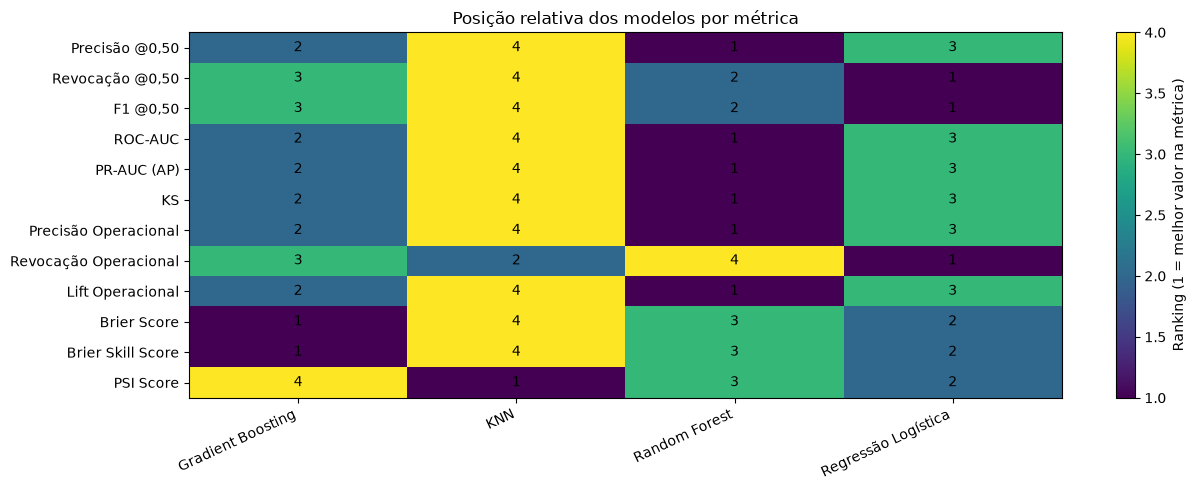

In [15]:
fig, ax = plt.subplots(
    figsize=(13, 5)
)

matriz_rank = ranking_metricas.T

imagem = ax.imshow(
    matriz_rank.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        len(matriz_rank.columns)
    )
)

ax.set_xticklabels(
    matriz_rank.columns,
    rotation=25,
    ha="right"
)

ax.set_yticks(
    np.arange(
        len(matriz_rank.index)
    )
)

ax.set_yticklabels(
    matriz_rank.index
)

for i in range(
    len(matriz_rank.index)
):
    for j in range(
        len(matriz_rank.columns)
    ):

        valor = matriz_rank.iloc[
            i,
            j
        ]

        if pd.notna(valor):
            ax.text(
                j,
                i,
                f"{valor:.0f}",
                ha="center",
                va="center"
            )

ax.set_title(
    "Posição relativa dos modelos por métrica"
)

fig.colorbar(
    imagem,
    ax=ax,
    label="Ranking (1 = melhor valor na métrica)"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "sintese_ranking_por_metrica.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# PARTE E — Intervalos de Confiança no OOT

## 15. Carregamento dos pipelines e probabilidades OOT

Os intervalos de confiança são calculados por bootstrap somente para quantificar a incerteza dos resultados já observados.

Nenhuma decisão de desenvolvimento é reaberta.


In [16]:
MAPA_ARQUIVOS = {
    "Regressão Logística":
        MODELS_DIR / "modelo_treino_regressao_logistica.joblib",

    "KNN":
        MODELS_DIR / "modelo_treino_knn.joblib",

    "Random Forest":
        MODELS_DIR / "modelo_treino_random_forest.joblib",

    "Gradient Boosting":
        MODELS_DIR / "modelo_treino_gradient_boosting.joblib"
}

modelos = {}

for nome in nomes_modelos:

    caminho = MAPA_ARQUIVOS[nome]

    if not caminho.exists():
        raise FileNotFoundError(
            f"Modelo ausente: {caminho}"
        )

    modelos[nome] = joblib.load(
        caminho
    )

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

df_oot = (
    df[df["Amostra"] == "OOT"]
    .sort_values("AAAA_MM")
    .reset_index(drop=True)
)

TARGET = "target"

PREDITORES_PADRAO = [
    "Região",
    "UF",
    "Cidade",
    "Sexo",
    "Faixa Etária",
    "Área",
    "Assunto",
    "Grupo Problema",
    "Problema",
    "Como Comprou Contratou",
    "Procurou Empresa"
]


def obter_features_modelo(modelo):

    for step_name in [
        "codificacao",
        "preprocessamento"
    ]:

        if step_name in modelo.named_steps:

            step = modelo.named_steps[
                step_name
            ]

            if hasattr(
                step,
                "feature_names_in_"
            ):
                return list(
                    step.feature_names_in_
                )

    return PREDITORES_PADRAO.copy()


features_por_modelo = {
    nome: obter_features_modelo(
        modelo
    )
    for nome, modelo in modelos.items()
}

y_oot = (
    df_oot[TARGET]
    .astype(int)
    .to_numpy()
)

probabilidades_oot = {}

for nome, modelo in modelos.items():

    features = features_por_modelo[
        nome
    ]

    probabilidades_oot[nome] = (
        modelo.predict_proba(
            df_oot[features]
        )[:, 1]
    )

print(
    f"Probabilidades OOT calculadas para "
    f"{len(modelos)} modelos."
)


Probabilidades OOT calculadas para 4 modelos.


## 16. Funções de métricas e regra operacional


In [17]:
def calcular_ks(
    y_true,
    prob
):
    fpr, tpr, _ = roc_curve(
        y_true,
        prob
    )

    return float(
        np.max(
            tpr - fpr
        )
    )


def pred_operacional(
    prob
):
    n = len(prob)

    if ESTRATEGIA == "threshold":

        return (
            prob >=
            float(
                THRESHOLD_OPERACIONAL
            )
        ).astype(int)

    if ESTRATEGIA == "top_k":

        n_top = int(
            np.ceil(
                n *
                float(TOP_K) /
                100
            )
        )

        ordem = np.argsort(
            -prob
        )

        pred = np.zeros(
            n,
            dtype=int
        )

        pred[
            ordem[:n_top]
        ] = 1

        return pred

    raise ValueError(
        f"Estratégia desconhecida: {ESTRATEGIA}"
    )


def metricas_oot(
    y,
    prob
):

    pred_050 = (
        prob >= 0.50
    ).astype(int)

    pred_op = pred_operacional(
        prob
    )

    precisao_op = precision_score(
        y,
        pred_op,
        zero_division=0
    )

    prevalencia = y.mean()

    lift_op = (
        precisao_op / prevalencia
        if prevalencia > 0
        else np.nan
    )

    return {
        "Precisão @0,50":
            precision_score(
                y,
                pred_050,
                zero_division=0
            ),

        "Revocação @0,50":
            recall_score(
                y,
                pred_050,
                zero_division=0
            ),

        "F1 @0,50":
            f1_score(
                y,
                pred_050,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y,
                prob
            ),

        "PR-AUC (AP)":
            average_precision_score(
                y,
                prob
            ),

        "KS":
            calcular_ks(
                y,
                prob
            ),

        "Precisão Operacional":
            precisao_op,

        "Revocação Operacional":
            recall_score(
                y,
                pred_op,
                zero_division=0
            ),

        "Lift Operacional":
            lift_op,

        "Cobertura Operacional":
            pred_op.mean(),

        "Brier Score":
            brier_score_loss(
                y,
                prob
            )
    }


## 17. Bootstrap dos indicadores OOT

O bootstrap é realizado de forma **pareada por observação**, preservando para cada registro o target e o score correspondente.

Para regras Top-k, o grupo priorizado é recalculado dentro de cada reamostragem usando exatamente a mesma proporção previamente congelada.


In [18]:
rng = np.random.default_rng(
    RANDOM_STATE
)

n = len(y_oot)

estimativas_ponto = {}
bootstrap_resultados = {
    nome: []
    for nome in nomes_modelos
}

for nome in nomes_modelos:

    estimativas_ponto[
        nome
    ] = metricas_oot(
        y_oot,
        probabilidades_oot[
            nome
        ]
    )

for b in range(
    N_BOOTSTRAP
):

    idx = rng.integers(
        0,
        n,
        size=n
    )

    y_b = y_oot[
        idx
    ]

    if len(
        np.unique(
            y_b
        )
    ) < 2:
        continue

    for nome in nomes_modelos:

        prob_b = (
            probabilidades_oot[
                nome
            ][idx]
        )

        try:
            metricas_b = metricas_oot(
                y_b,
                prob_b
            )

            bootstrap_resultados[
                nome
            ].append(
                metricas_b
            )

        except Exception:
            continue

print(
    f"Bootstrap concluído: "
    f"{N_BOOTSTRAP} reamostragens solicitadas."
)


Bootstrap concluído: 300 reamostragens solicitadas.


In [19]:
linhas_ic = []

q_inf = (
    100 *
    ALFA /
    2
)

q_sup = (
    100 *
    (1 - ALFA / 2)
)

for nome in nomes_modelos:

    boot_df = pd.DataFrame(
        bootstrap_resultados[
            nome
        ]
    )

    for metrica, estimativa in (
        estimativas_ponto[
            nome
        ].items()
    ):

        valores = (
            boot_df[
                metrica
            ]
            .dropna()
            .to_numpy()
        )

        if len(valores) == 0:
            inferior = np.nan
            superior = np.nan

        else:
            inferior = np.percentile(
                valores,
                q_inf
            )

            superior = np.percentile(
                valores,
                q_sup
            )

        linhas_ic.append({
            "Modelo": nome,
            "Métrica": metrica,
            "Estimativa": estimativa,
            "IC 95% Inferior": inferior,
            "IC 95% Superior": superior,
            "N Bootstrap Válidos":
                len(valores)
        })

intervalos_bootstrap = pd.DataFrame(
    linhas_ic
)

display(
    intervalos_bootstrap.round(5)
)

intervalos_bootstrap.to_csv(
    TABLES_DIR /
    "sintese_intervalos_bootstrap_oot.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Modelo,Métrica,Estimativa,IC 95% Inferior,IC 95% Superior,N Bootstrap Válidos
0,Regressão Logística,"Precisão @0,50",0.43261,0.42209,0.44320,300
1,Regressão Logística,"Revocação @0,50",0.39786,0.38745,0.40769,300
2,Regressão Logística,"F1 @0,50",0.41451,0.40547,0.42338,300
3,Regressão Logística,ROC-AUC,0.64326,0.63780,0.65033,300
4,Regressão Logística,PR-AUC (AP),0.41059,0.40094,0.42124,300
5,Regressão Logística,KS,0.21736,0.20783,0.22913,300
6,Regressão Logística,Precisão Operacional,0.47835,0.46426,0.49494,300
7,Regressão Logística,Revocação Operacional,0.18111,0.17425,0.18900,300
8,Regressão Logística,Lift Operacional,1.67686,1.62676,1.72917,300
9,Regressão Logística,Cobertura Operacional,0.10801,0.10476,0.11085,300


## 18. Quadro compacto com intervalos de confiança

Este quadro prioriza as métricas mais diretamente relacionadas à comparação final.


In [20]:
metricas_principais_ic = [
    "ROC-AUC",
    "PR-AUC (AP)",
    "Precisão Operacional",
    "Revocação Operacional",
    "Lift Operacional",
    "Brier Score"
]

ic_principais = (
    intervalos_bootstrap[
        intervalos_bootstrap[
            "Métrica"
        ].isin(
            metricas_principais_ic
        )
    ]
    .copy()
)

ic_principais[
    "Estimativa [IC95%]"
] = ic_principais.apply(
    lambda linha:
    (
        f"{linha['Estimativa']:.4f} "
        f"[{linha['IC 95% Inferior']:.4f}; "
        f"{linha['IC 95% Superior']:.4f}]"
    ),
    axis=1
)

quadro_ic = (
    ic_principais
    .pivot(
        index="Modelo",
        columns="Métrica",
        values="Estimativa [IC95%]"
    )
)

display(
    quadro_ic
)

quadro_ic.to_csv(
    TABLES_DIR /
    "sintese_quadro_ic95_oot.csv",
    sep=";",
    encoding="utf-8-sig"
)


Métrica,Brier Score,Lift Operacional,PR-AUC (AP),Precisão Operacional,ROC-AUC,Revocação Operacional
Modelo,,,,,,
Gradient Boosting,0.2087 [0.2071; 0.2101],1.7664 [1.7050; 1.8350],0.4111 [0.4014; 0.4205],0.5039 [0.4858; 0.5237],0.6450 [0.6388; 0.6521],0.1205 [0.1148; 0.1276]
KNN,0.2165 [0.2146; 0.2181],1.5342 [1.4822; 1.5928],0.3706 [0.3609; 0.3798],0.4376 [0.4209; 0.4548],0.6090 [0.6026; 0.6161],0.1492 [0.1425; 0.1560]
Random Forest,0.2094 [0.2079; 0.2106],1.7715 [1.6887; 1.8603],0.4158 [0.4059; 0.4259],0.5054 [0.4799; 0.5308],0.6481 [0.6421; 0.6546],0.0929 [0.0871; 0.0984]
Regressão Logística,0.2093 [0.2076; 0.2108],1.6769 [1.6268; 1.7292],0.4106 [0.4009; 0.4212],0.4783 [0.4643; 0.4949],0.6433 [0.6378; 0.6503],0.1811 [0.1743; 0.1890]


# PARTE F — Perfis Multidimensionais dos Modelos

## 19. Síntese automática por modelo

A descrição abaixo destaca características observadas, sem produzir um vencedor automático.


In [21]:
def melhor_modelo(
    metrica,
    direcao="max"
):

    temp = (
        sintese_multidimensional[
            [
                "Modelo",
                metrica
            ]
        ]
        .dropna()
    )

    if temp.empty:
        return None

    if direcao == "max":
        idx = temp[
            metrica
        ].idxmax()
    else:
        idx = temp[
            metrica
        ].idxmin()

    return temp.loc[
        idx,
        "Modelo"
    ]


print("=" * 90)
print("SÍNTESE MULTIDIMENSIONAL")
print("=" * 90)

print()
print(
    f"Maior ROC-AUC no OOT: "
    f"{melhor_modelo('ROC-AUC', 'max')}"
)

print(
    f"Maior PR-AUC no OOT: "
    f"{melhor_modelo('PR-AUC (AP)', 'max')}"
)

print(
    f"Maior Precisão Operacional: "
    f"{melhor_modelo('Precisão Operacional', 'max')}"
)

print(
    f"Maior Revocação Operacional: "
    f"{melhor_modelo('Revocação Operacional', 'max')}"
)

print(
    f"Maior Lift Operacional: "
    f"{melhor_modelo('Lift Operacional', 'max')}"
)

print(
    f"Menor Brier Score no OOT: "
    f"{melhor_modelo('Brier Score', 'min')}"
)

print(
    f"Maior Brier Skill Score no OOT: "
    f"{melhor_modelo('Brier Skill Score', 'max')}"
)

print(
    f"Menor PSI dos scores Treino→OOT: "
    f"{melhor_modelo('PSI Score', 'min')}"
)

print()
print(
    "Nenhum desses resultados, isoladamente, "
    "define o modelo final."
)


SÍNTESE MULTIDIMENSIONAL

Maior ROC-AUC no OOT: Random Forest
Maior PR-AUC no OOT: Random Forest
Maior Precisão Operacional: Random Forest
Maior Revocação Operacional: Regressão Logística
Maior Lift Operacional: Random Forest
Menor Brier Score no OOT: Gradient Boosting
Maior Brier Skill Score no OOT: Gradient Boosting
Menor PSI dos scores Treino→OOT: KNN

Nenhum desses resultados, isoladamente, define o modelo final.


## 20. Variáveis mais relevantes segundo cada modelo


In [22]:
for nome in nomes_modelos:

    temp = (
        top3_interpretabilidade[
            top3_interpretabilidade[
                "Modelo"
            ] == nome
        ]
        .sort_values(
            "Ranking"
        )
    )

    print()
    print(nome)

    for _, linha in temp.iterrows():

        print(
            f"- {int(linha['Ranking'])}º: "
            f"{linha['Variável']} "
            f"(Permutation Importance = "
            f"{linha['Importância Média']:.6f})"
        )



Regressão Logística
- 1º: Problema (Permutation Importance = 0.067357)
- 2º: Procurou Empresa (Permutation Importance = 0.024368)
- 3º: Grupo Problema (Permutation Importance = 0.005428)

KNN
- 1º: Problema (Permutation Importance = 0.032754)
- 2º: Grupo Problema (Permutation Importance = 0.023851)
- 3º: Procurou Empresa (Permutation Importance = 0.012374)

Random Forest
- 1º: Problema (Permutation Importance = 0.044561)
- 2º: Procurou Empresa (Permutation Importance = 0.015710)
- 3º: Grupo Problema (Permutation Importance = 0.007052)

Gradient Boosting
- 1º: Problema (Permutation Importance = 0.067182)
- 2º: Procurou Empresa (Permutation Importance = 0.019351)
- 3º: Como Comprou Contratou (Permutation Importance = 0.004137)


# PARTE G — Congelamento Manual do Modelo Final

## 21. Decisão final

A escolha do modelo final **não é automatizada**.

Preencha somente depois de revisar:

- desempenho no OOT;
- regra operacional;
- intervalos de confiança;
- calibração;
- estabilidade temporal;
- interpretabilidade;
- complexidade e aplicabilidade operacional.

Se ainda não houver decisão, mantenha `MODELO_FINAL = None`.


In [25]:
# ============================================================
# PREENCHER SOMENTE APÓS A SÍNTESE E DISCUSSÃO FINAL
# ============================================================

MODELO_FINAL = "Random Forest"

# Exemplos válidos:
# MODELO_FINAL = "Regressão Logística"
# MODELO_FINAL = "KNN"
# MODELO_FINAL = "Random Forest"
# MODELO_FINAL = "Gradient Boosting"

JUSTIFICATIVA_MODELO_FINAL = "JUSTIFICATIVA_MODELO_FINAL"

# Exemplo:
# JUSTIFICATIVA_MODELO_FINAL = (
#     "Modelo escolhido pela combinação entre desempenho discriminatório, "
#     "resultado operacional, estabilidade temporal, calibração e "
#     "interpretabilidade."
# )


## 22. Registro da decisão final


In [26]:
CONFIG_FINAL_FILE = (
    CONFIG_DIR /
    "configuracao_modelo_final.json"
)

if MODELO_FINAL is None:

    print(
        "Modelo final ainda não congelado. "
        "Revise a síntese multidimensional antes de preencher a decisão."
    )

else:

    if MODELO_FINAL not in nomes_modelos:
        raise ValueError(
            f"MODELO_FINAL inválido: {MODELO_FINAL}"
        )

    if (
        JUSTIFICATIVA_MODELO_FINAL is None
        or not str(
            JUSTIFICATIVA_MODELO_FINAL
        ).strip()
    ):
        raise ValueError(
            "Preencha JUSTIFICATIVA_MODELO_FINAL."
        )

    registro_final = {
        "modelo_final": MODELO_FINAL,
        "justificativa":
            JUSTIFICATIVA_MODELO_FINAL,
        "estrategia_operacional":
            ESTRATEGIA,
        "top_k_percentual":
            TOP_K,
        "threshold_operacional":
            THRESHOLD_OPERACIONAL,
        "avaliacao_oot_executada":
            True,
        "recalibracao_com_oot":
            False,
        "modelo_final_congelado":
            True
    }

    with CONFIG_FINAL_FILE.open(
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            registro_final,
            f,
            ensure_ascii=False,
            indent=2
        )

    print(
        f"Modelo final congelado: "
        f"{MODELO_FINAL}"
    )

    print(
        f"Arquivo salvo em: "
        f"{CONFIG_FINAL_FILE}"
    )


Modelo final congelado: Random Forest
Arquivo salvo em: C:\UnB\script_md\outputs\config\configuracao_modelo_final.json


# PARTE H — Checkpoint para Resultados e Discussões

## 23. Estrutura sugerida para a seção de resultados

Após a execução deste notebook, os resultados podem ser redigidos aproximadamente na seguinte sequência:

### A. Caracterização da amostra e preparação
- tamanho da base;
- proporção de avaliadas e não avaliadas;
- distribuição da classe-alvo;
- atributos selecionados;
- prevenção de leakage.

### B. Distribuição temporal
- Treino;
- Teste/Validação Operacional;
- OOT;
- mudança da prevalência de `Resolvida`.

### C. Desempenho dos classificadores
- Precision;
- Recall;
- F1;
- ROC-AUC;
- PR-AUC;
- KS.

### D. Desempenho operacional
- regra Top-k ou threshold;
- Precision operacional;
- Recall operacional;
- Lift;
- capacidade de atuação.

### E. Generalização temporal
- comparação Teste × OOT;
- intervalos de confiança;
- manutenção ou alteração das métricas.

### F. Calibração e estabilidade
- Brier;
- Brier Skill Score;
- curvas de calibração;
- PSI dos atributos;
- PSI dos scores.

### G. Interpretabilidade
- Permutation Importance;
- coeficientes;
- importâncias internas;
- SHAP quando disponível;
- convergência entre modelos.

### H. Síntese multidimensional
- pontos fortes e limitações de cada algoritmo;
- relação entre complexidade e ganho preditivo;
- adequação ao objetivo de negócio;
- justificativa da eventual escolha final.

## Próxima etapa

Se um modelo final for congelado, a próxima etapa poderá ser:

**11 — Aplicação do modelo final às reclamações `Não Avaliada`**

Essa aplicação deverá ser explicitamente apresentada como **uso do modelo em população sem rótulo**, e não como validação de desempenho.
